In [1]:
import sys
sys.path.append('../')

In [2]:

import re
import json
import os
from datetime import datetime
from tqdm import tqdm
import networkx as nx
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor, as_completed
from threading import Lock

from src.llm.engines import get_engine, invoke_engine

In [5]:
## Loading the prompt
prompt_template = open("prompt_templates/decomposition_prompt.txt").read()

placeholders = re.findall(r'\{\{(.*?)\}\}', prompt_template)
print("Placeholders found in prompt:")
for p in placeholders:
    print(f"- {p}")

Placeholders found in prompt:
- main_question
- sql_query


In [21]:
## Loading the queries
queries_path = "/Users/stalaei/Desktop/Projects/Spider2/spider2-snow/baselines/deep_queries/preprocessed_data/spider2-snow/spider2-snow_preprocessed.json"
queries = json.load(open(queries_path))

print(f"Number of queries: {len(queries)}")
print(f"Keys: {queries[0].keys()}")

# Create sublist of queries with non-empty query field
queries_with_sql = [q for q in queries if q.get("query", "").strip()]
print(f"\nNumber of queries with SQL: {len(queries_with_sql)}")


Number of queries: 547
Keys: dict_keys(['instance_id', 'instruction', 'db_id', 'external_knowledge', 'question_toks', 'query', 'No. of candidate columns', 'No. of gold tables'])

Number of queries with SQL: 121


In [7]:
def parse_llm_output(string):
    """
    Parses a JSON-formatted string into a list of dictionaries.

    Args:
        json_string (str): JSON string representing the LLM output.

    Returns:
        list: A list of dictionaries, each containing component details.
    """
    try:
        if "```python" in string:
            string = string.split("```python")[1].strip()
            string = string.split("```")[0].strip()
        if "```json" in string:
            string = string.split("```json")[1].strip()
            string = string.split("```")[0].strip()
        components = json.loads(string)
        return components
    except json.JSONDecodeError as e:
        print(f"Error decoding JSON: {e}")
        return []


In [3]:
def create_dag(components):
    """
    Creates a Directed Acyclic Graph (DAG) from a list of component dictionaries.

    Args:
        components (list): A list of dictionaries, each containing component details.

    Returns:
        DiGraph: A NetworkX directed graph representing the DAG.
    """
    G = nx.DiGraph()

    # Add nodes with their attributes
    for component in components:
        G.add_node(component['id'], description=component['description'],
                   equivalent_natural_question=component['equivalent_natural_question'])

    # Add edges based on dependencies
    for component in components:
        for dependency in component['dag_dependencies']:
            G.add_edge(dependency, component['id'])

    # Check for cycles
    if not nx.is_directed_acyclic_graph(G):
        raise ValueError("The graph contains cycles and is not a valid DAG.")

    return G

plt_lock = Lock()
def save_dag_as_pdf(dag, save_to_path):
    """
    Visualizes a Directed Acyclic Graph (DAG) in a bottom-up layout and saves it as a PDF.

    Args:
        dag (networkx.DiGraph): The DAG to visualize.
        save_to_path (str): The file path to save the PDF (e.g., 'path/to/graph.pdf').

    Returns:
        None
    """
    # Ensure the graph is a DAG
    if not nx.is_directed_acyclic_graph(dag):
        raise ValueError("The provided graph is not a Directed Acyclic Graph (DAG).")

    # Generate the layout using Graphviz's 'dot' with bottom-up hierarchy
    pos = nx.nx_agraph.graphviz_layout(dag, prog='dot', args='-Grankdir=BT')

    # Draw the graph
    plt.figure(figsize=(6, 8))  # Smaller figure size
    nx.draw(dag, pos, with_labels=True, node_size=3000, node_color='lightblue', 
            arrows=True, arrowsize=20, font_size=10, font_weight='bold', 
            edge_color='gray', node_shape='o')

    # Save the figure as a PDF
    plt.savefig(save_to_path, format='pdf', bbox_inches='tight')
    plt.close()


In [5]:
response = '''[
  {
    "id": "A",
    "description": "This subquery filters US publications that mention 'internet of things' in their abstracts. It extracts the filing date, application number, title, and title language. The aggregation handles cases where a patent has multiple abstracts in different languages.",
    "equivalent_natural_question": "Which U.S. publications contain the phrase 'internet of things' in their abstract, and what are their filing dates, application numbers, titles, and title languages?",
    "sql_query": "SELECT TO_DATE(CAST(ANY_VALUE(patentsdb.\\"filing_date\\") AS STRING), 'YYYYMMDD') AS Patent_Filing_Date, patentsdb.\\"application_number\\" AS Patent_Application_Number, MAX(abstract_info.value:\\"text\\") AS Patent_Title, MAX(abstract_info.value:\\"language\\") AS Patent_Title_Language FROM PATENTS.PATENTS.PUBLICATIONS AS patentsdb, LATERAL FLATTEN(input => patentsdb.\\"abstract_localized\\") AS abstract_info WHERE LOWER(abstract_info.value:\\"text\\") LIKE '%internet of things%' AND patentsdb.\\"country_code\\" = 'US' GROUP BY Patent_Application_Number",
    "dag_dependencies": []
  },
  {
    "id": "B", 
    "description": "This subquery generates a series of dates from 2008-01-01 to 2022-12-31.  It creates a placeholder for the number of patents, initialized to 0. This will be used later to ensure all months are included in the final count, even those with no patent filings.",
    "equivalent_natural_question": "Can we create a table containing every single day from January 1, 2008, to December 31, 2022, along with a placeholder column for counting things later?",
    "sql_query": "SELECT DATEADD(day, seq4(), DATE '2008-01-01') AS day, 0 AS Number_of_Patents FROM TABLE(GENERATOR(ROWCOUNT => 5479)) ORDER BY day",
    "dag_dependencies": []
  },
  {
    "id": "C",
    "description": "This query joins the date series with the patent matches on their respective dates. It then groups the results by year and month, counting the number of patent applications in each month. The left join ensures that all months from the date series are included, even those without matching patent filings.",
    "equivalent_natural_question": "How many U.S. publications related to IoT (where the abstract includes the phrase 'internet of things') were filed each month from 2008 to 2022, including months with no filings?",
    "sql_query": "WITH Patent_Matches AS (SELECT TO_DATE(CAST(ANY_VALUE(patentsdb.\\"filing_date\\") AS STRING), 'YYYYMMDD') AS Patent_Filing_Date, patentsdb.\\"application_number\\" AS Patent_Application_Number, MAX(abstract_info.value:\\"text\\") AS Patent_Title, MAX(abstract_info.value:\\"language\\") AS Patent_Title_Language FROM PATENTS.PATENTS.PUBLICATIONS AS patentsdb, LATERAL FLATTEN(input => patentsdb.\\"abstract_localized\\") AS abstract_info WHERE LOWER(abstract_info.value:\\"text\\") LIKE '%internet of things%' AND patentsdb.\\"country_code\\" = 'US' GROUP BY Patent_Application_Number), Date_Series_Table AS (SELECT DATEADD(day, seq4(), DATE '2008-01-01') AS day, 0 AS Number_of_Patents FROM TABLE(GENERATOR(ROWCOUNT => 5479)) ORDER BY day) SELECT TO_CHAR(Date_Series_Table.day, 'YYYY-MM') AS Patent_Date_YearMonth, COUNT(Patent_Matches.Patent_Application_Number) AS Number_of_Patent_Applications FROM Date_Series_Table LEFT JOIN Patent_Matches ON Date_Series_Table.day = Patent_Matches.Patent_Filing_Date WHERE Date_Series_Table.day < DATE '2023-01-01' GROUP BY TO_CHAR(Date_Series_Table.day, 'YYYY-MM') ORDER BY Patent_Date_YearMonth",
    "dag_dependencies": ["A", "B"]
  }
]'''

components = json.loads(response)
dag = create_dag(components)
save_dag_as_pdf(dag, 'test.pdf')


In [9]:
def process_query_packet(query_packet, engine, log_directory, prompt_template):
    try:
        query_id = query_packet["instance_id"]
        question = query_packet["instruction"]
        sql_query = query_packet["query"]
        
        prompt = prompt_template.format(main_question=question, sql_query=sql_query)
        
        # Generate LLM response
        response = invoke_engine(engine, prompt)
        
        # Save input/output log
        log_path = os.path.join(log_directory, f"log_{query_id}.txt")
        with open(log_path, "w") as f:
            f.write(f"Query ID: {query_id}\n")
            f.write(f"\n\n##### Prompt #####\n\n")
            f.write(f"{prompt}\n")
            f.write(f"\n\n##### Response #####\n\n")
            f.write(f"{response}\n")
        
        # Parse and save DAG
        components = parse_llm_output(response)
        dag = create_dag(components)
        
        # Save DAG as JSON
        dag_json_path = os.path.join(log_directory, f"dag_{query_id}.json")
        with open(dag_json_path, "w") as f:
            json.dump(components, f, indent=4)
        
        # Save DAG visualization with lock to prevent concurrent file access
        with plt_lock:
            dag_pdf_path = os.path.join(log_directory, f"dag_visual_{query_id}.pdf")
            save_dag_as_pdf(dag, dag_pdf_path)
        
        return dag, components
    except Exception as e:
        print(f"Error processing query {query_id}: {e}")

In [13]:
engine = get_engine("gemini-1.5-pro-002")
log_directory = f"/Users/stalaei/Desktop/Projects/Spider2/notebooks/logs/gemini-1.5-pro-002-test"
# Create log directory if it doesn't exist
if not os.path.exists(log_directory):
    os.makedirs(log_directory)

prompt_template = open("decomposition_prompt.txt").read()
first_packet = queries_with_sql[0]

query_id = first_packet["instance_id"]
question = first_packet["instruction"]
sql_query = first_packet["query"]
prompt = prompt_template.format(main_question=question, sql_query=sql_query)
print(prompt)

### Task Instructions
You are tasked with breaking down a complex SQL query into its individual sub-components. Each sub-component represents a logical part of the query and must include the following elements:

1. **Component ID**: A unique identifier for the sub-component (e.g., A, B, C, etc.).
2. **Description**: A clear explanation of what this sub-component does in the context of the SQL query.
3. **Equivalent Natural Question**: A self-contained and natural language question that explains what this sub-component is doing without relying on the other sub-components for context.
4. **DAG Dependencies**: A list of IDs of the sub-components that this one depends on. If it is independent, this list should be empty.

You will then output the results as a Python list of JSON objects, where each object contains the above fields.

### Example Input
Here is an example of the main question and corresponding SQL query to be broken down:

#### Main Question:
What is the average balance of the

In [14]:
process_query_packet(first_packet, engine, log_directory, prompt_template)

(<networkx.classes.digraph.DiGraph at 0x148feb8b0>,
 [{'id': 'A',
   'description': "Extracts the assignee and filing date for patent applications related to category 'A61'. It uses FIRST_VALUE to ensure each application number is associated with a single assignee and filing date.",
   'equivalent_natural_question': "For each patent application classified under category 'A61', who is the primary assignee and when was it filed?",
   'dag_dependencies': []},
  {'id': 'B',
   'description': 'Groups the results from the previous step by application number to eliminate duplicates, ensuring each application is counted only once.',
   'equivalent_natural_question': "From the list of 'A61' patent applications and their assignees, can we get a distinct list where each application appears only once?",
   'dag_dependencies': ['A']},
  {'id': 'C',
   'description': 'Counts the number of applications for each assignee per year. It extracts the assignee name from the nested assignee_harmonized field

I0000 00:00:1738115201.773068 5838885 fork_posix.cc:75] Other threads are currently calling into gRPC, skipping fork() handlers
  6%|▌         | 7/121 [00:16<03:06,  1.64s/it]

Error processing query sf_bq216: <matplotlib.backends.backend_mixed.MixedModeRenderer object at 0x14beb4ac0>
Error processing query sf_bq221: <matplotlib.backends.backend_mixed.MixedModeRenderer object at 0x14beb60b0>


 52%|█████▏    | 63/121 [01:49<01:45,  1.81s/it]Retrying langchain_google_vertexai.llms._completion_with_retry.<locals>._completion_with_retry_inner in 4.0 seconds as it raised ResourceExhausted: 429 Resource exhausted. Please try again later. Please refer to https://cloud.google.com/vertex-ai/generative-ai/docs/error-code-429 for more details..
Retrying langchain_google_vertexai.llms._completion_with_retry.<locals>._completion_with_retry_inner in 4.0 seconds as it raised ResourceExhausted: 429 Resource exhausted. Please try again later. Please refer to https://cloud.google.com/vertex-ai/generative-ai/docs/error-code-429 for more details..
100%|██████████| 121/121 [04:04<00:00,  2.02s/it]


Error in callback <function _draw_all_if_interactive at 0x10e921360> (for post_execute), with arguments args (),kwargs {}:


Done: <matplotlib.backends.backend_agg.RendererAgg object at 0x14d62e8f0>

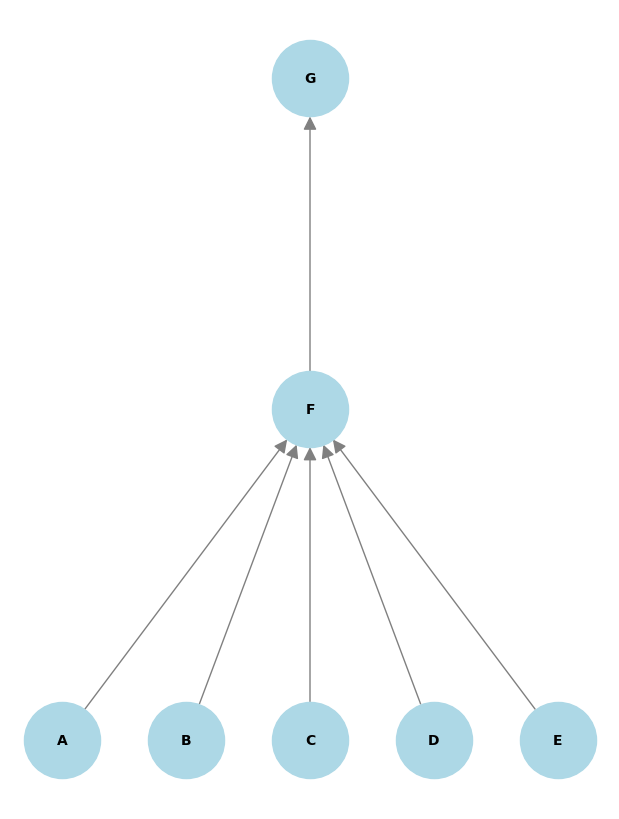

Done: <matplotlib.backends.backend_agg.RendererAgg object at 0x14d62e8f0>

<Figure size 600x800 with 1 Axes>

In [15]:
## Decomposing the queries
engine_name = "gemini-1.5-pro-002"
engine = get_engine(engine_name)
log_directory = f"/Users/stalaei/Desktop/Projects/Spider2/notebooks/logs/{engine_name}-{datetime.now().strftime('%Y-%m-%d-%H-%M-%S')}"
# Create log directory if it doesn't exist
if not os.path.exists(log_directory):
    os.makedirs(log_directory)

with ThreadPoolExecutor(max_workers=10) as executor:
    futures = []
    for query_packet in queries_with_sql:
        future = executor.submit(process_query_packet, query_packet, engine, log_directory, prompt_template)
        futures.append(future)
    
    for future in tqdm(as_completed(futures), total=len(futures)):
        future.result()

In [30]:
bad_ids = [
    "sf_local355"
]
for id in bad_ids:
    file_path = f"./logs/gemini-1.5-pro-002-2025-01-28-16-48-13/dag_{id}.json"
    dag = json.load(open(file_path))
    dag = create_dag(dag)
    save_dag_as_pdf(dag, f"logs/gemini-1.5-pro-002-2025-01-28-16-48-13/dag_visual_{id}.pdf")


In [ ]:
import os

log_dir = "logs/gemini-1.5-pro-002-2025-01-28-16-48-13"
pdf_files = [f for f in os.listdir(log_dir) if f.endswith('.pdf')]
print(f"Number of PDF files in {log_dir}: {len(pdf_files)}")


In [ ]:
sf_local210, sf_bq033

In [ ]:
sf_bq193